## Pelabelan aplikasi Dana

In [5]:
import pandas as pd

data = pd.read_csv("../../Preprocess/PreprocessDana/DatasetPreprocessDana/Tahap4Preprocessing.csv")
print(data.head())

                                         Review text  \
0                                       keren sekali   
1  fitur dana cicil tidak bisa di akses padahal s...   
2  saya sempet kesel waktu itu, jadi saya beli pa...   
3                            Belum menerima hasil,..   
4                                membantu sekali.tks   

                                          clean_text  \
0                                       keren sekali   
1  fitur dana cicil tidak bisa akses padahal syar...   
2  saya sempet kesel waktu jadi saya beli paketan...   
3                               belum menerima hasil   
4                                 membantu sekalitks   

                                    normalisasi_text  \
0                                       keren sekali   
1  fitur dana cicil tidak bisa akses padahal syar...   
2  saya sempat kesel waktu jadi saya beli paketan...   
3                               belum menerima hasil   
4                                 membantu sek

In [6]:
# Cek apakah ada missing value di dalam dataset
data.isnull().sum()

Review text         0
clean_text          0
normalisasi_text    0
tokenize            0
stopword_removal    0
steming_data        0
dtype: int64

In [9]:
import pandas as pd
import csv

# Membaca kamus 
positive_path = "../../kamus/positive.tsv"
negative_path = "../../kamus/negative.tsv"

positive_data = pd.read_csv(positive_path, sep='\t', header=None, names=['word', 'score'], skiprows=1, encoding='utf-8')
negative_data = pd.read_csv(negative_path, sep='\t', header=None, names=['word', 'score'], skiprows=1, encoding='utf-8')

# Buat kamus dengan huruf kecil dan tanpa spasi
lexicon_positive = dict(zip(positive_data['word'].str.strip().str.lower(), positive_data['score'].astype(int)))
lexicon_negative = dict(zip(negative_data['word'].str.strip().str.lower(), negative_data['score'].astype(int)))

print(f"Kata positif: {len(lexicon_positive)} | Kata negatif: {len(lexicon_negative)}")

# Logika skoring kata, penentuan polaritas berdasarkan skor
def sentiment_analysis_lexicon(text):
    score = 0
    for word in str(text).lower().split():
        word = word.strip()
        if word in lexicon_positive:
            score += lexicon_positive[word]
        elif word in lexicon_negative:
            score -= abs(lexicon_negative[word])
    
    if score > 0:
        polarity = 'positive'
    elif score < 0:
        polarity = 'negative'
    else:
        polarity = 'neutral'

    return score, polarity

data[['score', 'label']] = data['steming_data'].apply(
    lambda x: pd.Series(sentiment_analysis_lexicon(x))
)

print(data[['steming_data', 'score', 'label']])


Kata positif: 3607 | Kata negatif: 6607
                                           steming_data  score     label
0                                                 keren      0   neutral
1                   fitur dana cicil akses syarat penuh      6  positive
2     kesel beli paket dana kepake nyalain duolingo ...      4  positive
3                                          terima hasil      5  positive
4                                       bantu sekalitks      3  positive
...                                                 ...    ...       ...
9878  parah dana kirim nomer aktif hasil daftar dana...     23  positive
9879                                   aplikasi thebest     -4  negative
9880                                              bagus      2  positive
9881                         dana instant muncul muncul      6  positive
9882  bagong dana beli data masuk saldo ambil dana b...     -4  negative

[9883 rows x 3 columns]


In [ ]:
import os
folder_tujuan = 'DatasetPelabelanDana' 

if not os.path.exists(folder_tujuan):
    os.makedirs(folder_tujuan)

path_output = os.path.join(folder_tujuan, 'Tahap5HasilPelabelan.csv')
data.to_csv(path_output, index=False, encoding='utf-8')
print(f"File berhasil disimpan di: {path_output}")
data.info()

File berhasil disimpan di: DatasetPelabelanDana\Tahap5HasilPelabelan.csv
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9883 entries, 0 to 9882
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Review text       9883 non-null   object
 1   clean_text        9883 non-null   object
 2   normalisasi_text  9883 non-null   object
 3   tokenize          9883 non-null   object
 4   stopword_removal  9883 non-null   object
 5   steming_data      9883 non-null   object
 6   score             9883 non-null   int64 
 7   label             9883 non-null   object
dtypes: int64(1), object(7)
memory usage: 617.8+ KB


## Pemodelan tanpa smote

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# --- 1. LOAD DATASET ---
file_path = "../../Pelabelan/PelabelanDana/DatasetPelabelanDana/Tahap5HasilPelabelan.csv"

try:
    data = pd.read_csv(file_path)
    print(f"[SUKSES] Data berhasil dimuat dari: {file_path}")
except FileNotFoundError:
    print(f"[ERROR] File tidak ditemukan di: {file_path}")
    print("Pastikan path file sudah benar.")
    exit() # Hentikan program jika file tidak ada

# --- 2. PERSIAPAN DATA (DATA PREPARATION) ---

# Pastikan kolom target ada
if 'steming_data' not in data.columns or 'Label' not in data.columns:
    print("[ERROR] Kolom 'steming_data' atau 'Label' tidak ditemukan.")
    print(f"Kolom yang tersedia: {list(data.columns)}")
    exit()

print(f"Jumlah data awal: {len(data)}")

# Konversi ke string (jaga-jaga jika ada angka) dan drop NaN
data['steming_data'] = data['steming_data'].astype(str)
data.dropna(subset=['steming_data', 'label'], inplace=True)

# Hapus data yang isinya hanya spasi kosong atau string kosong
data = data[data['steming_data'].str.strip() != '']
data = data[data['steming_data'] != 'nan'] # Hapus string "nan" literal jika ada

print(f"Jumlah data bersih: {len(data)}")

# Cek sebaran data (Penting untuk melihat imbalance)
print("\nSebaran Data per Label:")
print(data['label'].value_counts())

X_text = data['steming_data']
y = data['label']

# --- 3. EKSTRAKSI FITUR (TF-IDF) ---
print("\nMelakukan ekstraksi fitur TF-IDF...")
# max_features=5000 mengambil 5000 kata teratas berdasarkan frekuensi
tfidf = TfidfVectorizer(max_features=5000) 
X = tfidf.fit_transform(X_text)

print(f"Ukuran Matriks TF-IDF: {X.shape}") 

# --- 4. SPLIT DATA ---
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# --- 5. PELATIHAN MODEL SVM ---
print("\nMelatih Model SVM...")

# PERBAIKAN: Tambahkan class_weight='balanced'
# Ini membantu jika jumlah data Positif jauh lebih banyak dari Negatif/Netral
svm_model = SVC(kernel='linear', class_weight='balanced', random_state=42) 
svm_model.fit(X_train, y_train)

print("Pelatihan selesai!")

# --- 6. EVALUASI MODEL ---
y_pred = svm_model.predict(X_test)
akurasi = accuracy_score(y_test, y_pred)

print(f"\n--- HASIL EVALUASI ---")
print(f"Akurasi Model: {akurasi * 100:.2f}%")

print("\nClassification Report:")
print(classification_report(y_test, y_pred))


[SUKSES] Data berhasil dimuat dari: ../../Pelabelan/PelabelanDana/DatasetPelabelanDana/Tahap5HasilPelabelan.csv
[ERROR] Kolom 'steming_data' atau 'Label' tidak ditemukan.
Kolom yang tersedia: ['Review text', 'clean_text', 'normalisasi_text', 'tokenize', 'stopword_removal', 'steming_data', 'score', 'label']
Jumlah data awal: 9883
Jumlah data bersih: 9883

Sebaran Data per Label:
label
positive    7488
negative    1396
neutral      999
Name: count, dtype: int64

Melakukan ekstraksi fitur TF-IDF...
Ukuran Matriks TF-IDF: (9883, 5000)

Melatih Model SVM...
Pelatihan selesai!

--- HASIL EVALUASI ---
Akurasi Model: 88.62%

Classification Report:
              precision    recall  f1-score   support

    negative       0.75      0.89      0.81       276
     neutral       0.59      0.82      0.69       213
    positive       0.99      0.89      0.94      1488

    accuracy                           0.89      1977
   macro avg       0.77      0.87      0.81      1977
weighted avg       0.91   

: 

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB  # <--- IMPORT BARU
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# --- 1. LOAD DATASET ---
# Note: Python string path sebaiknya raw string (r"...") atau forward slash (/) semua
file_path = "../../Pelabelan/PelabelanDana/DatasetPelabelanDana/Tahap5HasilPelabelan.csv"

try:
    data = pd.read_csv(file_path)
    print(f"[SUKSES] Data berhasil dimuat dari: {file_path}")
except FileNotFoundError:
    print(f"[ERROR] File tidak ditemukan di: {file_path}")
    exit()

# --- 2. PERSIAPAN DATA (DATA PREPARATION) ---

# Perbaiki pengecekan kolom (gunakan 'label' huruf kecil sesuai error sebelumnya)
if 'steming_data' not in data.columns or 'label' not in data.columns:
    print("[ERROR] Kolom 'steming_data' atau 'label' tidak ditemukan.")
    print(f"Kolom yang tersedia: {list(data.columns)}")
    exit()

print(f"Jumlah data awal: {len(data)}")

# Konversi ke string & Bersihkan NaN
data['steming_data'] = data['steming_data'].astype(str)
data.dropna(subset=['steming_data', 'label'], inplace=True)

# Hapus data kosong/spasi saja
data = data[data['steming_data'].str.strip() != '']
data = data[data['steming_data'] != 'nan']

print(f"Jumlah data bersih: {len(data)}")

# Cek sebaran data
print("\nSebaran Data per Label:")
print(data['label'].value_counts())

X_text = data['steming_data']
y = data['label']

# --- 3. EKSTRAKSI FITUR (TF-IDF) ---
print("\nMelakukan ekstraksi fitur TF-IDF...")
tfidf = TfidfVectorizer(max_features=5000) 
X = tfidf.fit_transform(X_text)

print(f"Ukuran Matriks TF-IDF: {X.shape}") 

# --- 4. SPLIT DATA ---
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# --- 5. PELATIHAN MODEL NAIVE BAYES ---
print("\nMelatih Model Naive Bayes (MultinomialNB)...")

# GANTI SVM DENGAN NAIVE BAYES DI SINI
nb_model = MultinomialNB() 
nb_model.fit(X_train, y_train)

print("Pelatihan selesai!")

# --- 6. EVALUASI MODEL ---
y_pred = nb_model.predict(X_test)
akurasi = accuracy_score(y_test, y_pred)

print(f"\n--- HASIL EVALUASI NAIVE BAYES ---")
print(f"Akurasi Model: {akurasi * 100:.2f}%")

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

[SUKSES] Data berhasil dimuat dari: ../../Pelabelan/PelabelanDana/DatasetPelabelanDana/Tahap5HasilPelabelan.csv
Jumlah data awal: 9883
Jumlah data bersih: 9883

Sebaran Data per Label:
label
positive    7488
negative    1396
neutral      999
Name: count, dtype: int64

Melakukan ekstraksi fitur TF-IDF...
Ukuran Matriks TF-IDF: (9883, 5000)

Melatih Model Naive Bayes (MultinomialNB)...
Pelatihan selesai!

--- HASIL EVALUASI NAIVE BAYES ---
Akurasi Model: 76.18%

Classification Report:
              precision    recall  f1-score   support

    negative       0.88      0.05      0.10       276
     neutral       1.00      0.02      0.05       213
    positive       0.76      1.00      0.86      1488

    accuracy                           0.76      1977
   macro avg       0.88      0.36      0.34      1977
weighted avg       0.80      0.76      0.67      1977



## Pelabelan dengan smote

[SUKSES] Data berhasil dimuat dari: ../../Pelabelan/PelabelanDana/DatasetPelabelanDana/Tahap5HasilPelabelan.csv
Jumlah data bersih: 9883

Sebaran Data Asli:
label
positive    7488
negative    1396
neutral      999
Name: count, dtype: int64

Melakukan ekstraksi fitur TF-IDF...

Data Training Asli: 7906
Data Testing: 1977

Menerapkan SMOTE pada data training...
Data Training setelah SMOTE: 18000
Sebaran Data Training Baru:
label
positive    6000
neutral     6000
negative    6000
Name: count, dtype: int64

Melatih Model SVM dengan data SMOTE...
Pelatihan selesai!

--- HASIL EVALUASI (SVM + SMOTE) ---
Akurasi Model: 91.30%

Classification Report:
              precision    recall  f1-score   support

    negative       0.81      0.90      0.85       276
     neutral       0.67      0.81      0.73       213
    positive       0.98      0.93      0.95      1488

    accuracy                           0.91      1977
   macro avg       0.82      0.88      0.85      1977
weighted avg       0.92

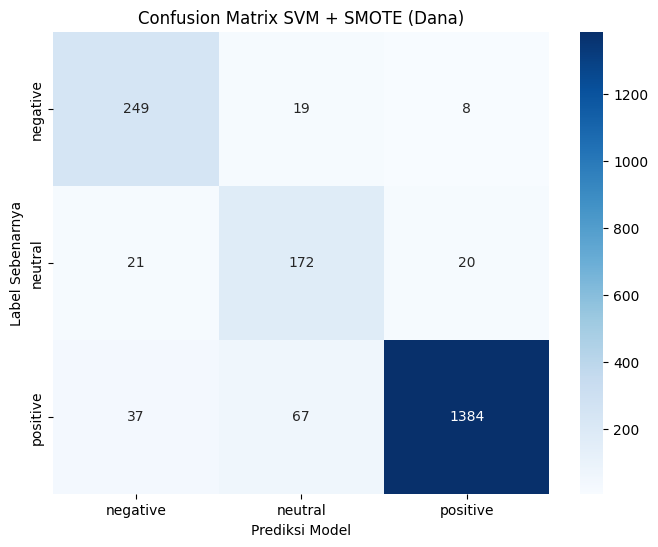

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
# --- IMPORT BARU UNTUK SMOTE ---
from imblearn.over_sampling import SMOTE 

# --- 1. LOAD DATASET ---
file_path = "../../Pelabelan/PelabelanDana/DatasetPelabelanDana/Tahap5HasilPelabelan.csv"

try:
    data = pd.read_csv(file_path)
    print(f"[SUKSES] Data berhasil dimuat dari: {file_path}")
except FileNotFoundError:
    print(f"[ERROR] File tidak ditemukan di: {file_path}")
    exit()

# --- 2. PERSIAPAN DATA ---

# Perbaiki konsistensi nama kolom (gunakan 'label' kecil)
if 'steming_data' not in data.columns or 'label' not in data.columns:
    print("[ERROR] Kolom 'steming_data' atau 'label' tidak ditemukan.")
    print(f"Kolom yang tersedia: {list(data.columns)}")
    exit()

# Bersihkan Data
data['steming_data'] = data['steming_data'].astype(str)
data.dropna(subset=['steming_data', 'label'], inplace=True)
data = data[data['steming_data'].str.strip() != '']
data = data[data['steming_data'] != 'nan']

print(f"Jumlah data bersih: {len(data)}")

# Cek sebaran data SEBELUM SMOTE
print("\nSebaran Data Asli:")
print(data['label'].value_counts())

X_text = data['steming_data']
y = data['label']

# --- 3. EKSTRAKSI FITUR (TF-IDF) ---
print("\nMelakukan ekstraksi fitur TF-IDF...")
tfidf = TfidfVectorizer(max_features=5000) 
X = tfidf.fit_transform(X_text)

# --- 4. SPLIT DATA ---
# Pisahkan dulu Training dan Testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"\nData Training Asli: {X_train.shape[0]}")
print(f"Data Testing: {X_test.shape[0]}")

# --- 5. PENERAPAN SMOTE (Hanya pada Training Data) ---
print("\nMenerapkan SMOTE pada data training...")
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

# Cek hasil resampling
print(f"Data Training setelah SMOTE: {X_train_resampled.shape[0]}")
print("Sebaran Data Training Baru:")
print(pd.Series(y_train_resampled).value_counts())

# --- 6. PELATIHAN MODEL SVM ---
print("\nMelatih Model SVM dengan data SMOTE...")

# Catatan: Karena data sudah seimbang berkat SMOTE, 
# kita bisa menghapus class_weight='balanced' atau membiarkannya (opsional).
# Di sini saya hapus agar kita melihat murni efek SMOTE.
svm_model = SVC(kernel='linear', random_state=42) 
svm_model.fit(X_train_resampled, y_train_resampled)

print("Pelatihan selesai!")

# --- 7. EVALUASI MODEL ---
# Prediksi tetap menggunakan X_test yang ASLI (tidak kena SMOTE)
y_pred = svm_model.predict(X_test)
akurasi = accuracy_score(y_test, y_pred)

print(f"\n--- HASIL EVALUASI (SVM + SMOTE) ---")
print(f"Akurasi Model: {akurasi * 100:.2f}%")

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# --- 8. VISUALISASI ---
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=svm_model.classes_, 
            yticklabels=svm_model.classes_)
plt.title('Confusion Matrix SVM + SMOTE (Dana)')
plt.ylabel('Label Sebenarnya')
plt.xlabel('Prediksi Model')
plt.show()

[SUKSES] Data berhasil dimuat dari: ../../Pelabelan/PelabelanDana/DatasetPelabelanDana/Tahap5HasilPelabelan.csv
Jumlah data awal: 9883
Jumlah data bersih: 9883

Sebaran Data Asli:
label
positive    7488
negative    1396
neutral      999
Name: count, dtype: int64

Melakukan ekstraksi fitur TF-IDF...

Data Training Asli: 7906
Data Testing: 1977

Menerapkan SMOTE pada data training...
Data Training setelah SMOTE: 18000
Sebaran Data Training Baru (Seimbang):
label
positive    6000
neutral     6000
negative    6000
Name: count, dtype: int64

Melatih Model Naive Bayes dengan data SMOTE...
Pelatihan selesai!

--- HASIL EVALUASI NAIVE BAYES + SMOTE ---
Akurasi Model: 79.16%

Classification Report:
              precision    recall  f1-score   support

    negative       0.48      0.80      0.60       276
     neutral       0.51      0.51      0.51       213
    positive       0.95      0.83      0.88      1488

    accuracy                           0.79      1977
   macro avg       0.65      

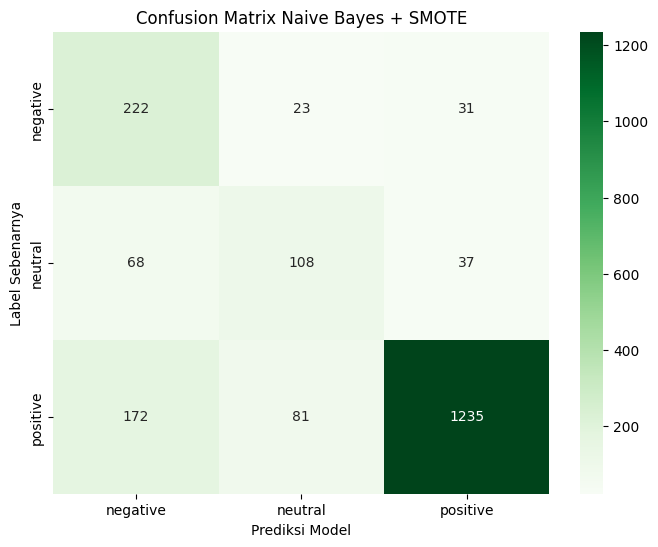

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB  # Tetap pakai Naive Bayes
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
# --- IMPORT BARU UNTUK SMOTE ---
from imblearn.over_sampling import SMOTE 

# --- 1. LOAD DATASET ---
file_path = "../../Pelabelan/PelabelanDana/DatasetPelabelanDana/Tahap5HasilPelabelan.csv"

try:
    data = pd.read_csv(file_path)
    print(f"[SUKSES] Data berhasil dimuat dari: {file_path}")
except FileNotFoundError:
    print(f"[ERROR] File tidak ditemukan di: {file_path}")
    print("Pastikan path file sudah benar.")
    exit()

# --- 2. PERSIAPAN DATA (DATA PREPARATION) ---

if 'steming_data' not in data.columns or 'label' not in data.columns:
    print("[ERROR] Kolom 'steming_data' atau 'label' tidak ditemukan.")
    exit()

print(f"Jumlah data awal: {len(data)}")

# Bersihkan Data
data['steming_data'] = data['steming_data'].astype(str)
data.dropna(subset=['steming_data', 'label'], inplace=True)
data = data[data['steming_data'].str.strip() != '']
data = data[data['steming_data'] != 'nan']

print(f"Jumlah data bersih: {len(data)}")

# Cek sebaran data SEBELUM SMOTE
print("\nSebaran Data Asli:")
print(data['label'].value_counts())

X_text = data['steming_data']
y = data['label']

# --- 3. EKSTRAKSI FITUR (TF-IDF) ---
print("\nMelakukan ekstraksi fitur TF-IDF...")
tfidf = TfidfVectorizer(max_features=5000) 
X = tfidf.fit_transform(X_text)

# --- 4. SPLIT DATA ---
# Pisahkan dulu Training dan Testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"\nData Training Asli: {X_train.shape[0]}")
print(f"Data Testing: {X_test.shape[0]}")

# --- 5. PENERAPAN SMOTE (Resampling) ---
print("\nMenerapkan SMOTE pada data training...")
# SMOTE akan membuat jumlah data per kelas menjadi seimbang (sama rata)
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

# Cek hasil resampling
print(f"Data Training setelah SMOTE: {X_train_resampled.shape[0]}")
print("Sebaran Data Training Baru (Seimbang):")
print(pd.Series(y_train_resampled).value_counts())

# --- 6. PELATIHAN MODEL NAIVE BAYES ---
print("\nMelatih Model Naive Bayes dengan data SMOTE...")

nb_model = MultinomialNB() 
# Latih menggunakan data hasil SMOTE
nb_model.fit(X_train_resampled, y_train_resampled)

print("Pelatihan selesai!")

# --- 7. EVALUASI MODEL ---
# Prediksi tetap menggunakan X_test yang ASLI (tanpa SMOTE)
y_pred = nb_model.predict(X_test)
akurasi = accuracy_score(y_test, y_pred)

print(f"\n--- HASIL EVALUASI NAIVE BAYES + SMOTE ---")
print(f"Akurasi Model: {akurasi * 100:.2f}%")

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# --- 8. VISUALISASI CONFUSION MATRIX ---
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', 
            xticklabels=nb_model.classes_, 
            yticklabels=nb_model.classes_)
plt.title('Confusion Matrix Naive Bayes + SMOTE')
plt.ylabel('Label Sebenarnya')
plt.xlabel('Prediksi Model')
plt.show()